<a href="https://colab.research.google.com/github/madhu-sudhana07/madhusudhana/blob/main/Porter_Biz_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Porter: Neural Networks Regression Business Case**

Dataset Explanation: Porter Data
Each row in this dataset corresponds to a unique delivery, and each column represents
a feature critical in predicting delivery times. The dataset 'Porter Data' includes the
following variables:
1. market_id: An integer ID indicating the market area of the restaurant.
2. created_at: Timestamp of when the order was placed.
3. actual_delivery_time: Timestamp of when the order was delivered.
4. store_primary_category: Category classification of the restaurant.
5. order_protocol: Numeric code representing the mode of order placement (e.g.,
through Porter, direct call, pre-booking, third-party platform).
6. total_items_subtotal: A combined feature detailing the total number of items in
the order and the final price of the order before taxes and fees.
7. num_distinct_items: Count of different items in the order.
8. min_item_price: Price of the least expensive item in the order.
9. max_item_price: Price of the most expensive item in the order.
10.total_onshift_partners: Number of delivery partners on duty when the order was
placed.
11. total_busy_partners: Number of delivery partners busy with other tasks at the
order placement time.
12.total_outstanding_orders: Total count of orders pending at the time.

Note: The target variable for this study, 'estimated_delivery_time', is to be derived from
the difference between 'created_at' and 'actual_delivery_time'.

Q. Why
is predicting delivery times crucial
for Porter?

Ans. Accurate delivery time prediction is a cornerstone of reliable logistics operations, directly influencing customer experience, operational agility, and profitability.


In [ ]:
# importing required modules
import warnings
warnings.filterwarnings("ignore")
#for reading and handling the data
import pandas as pd
import numpy as np
import os

#for visualizinng and analyzing it
import matplotlib.pyplot as plt
import seaborn as sns

#data preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#random forest model training
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

#ann training
from tensorflow.keras import Model
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization,LeakyReLU
from sklearn.model_selection import train_test_split
from tensorflow.keras.losses import MeanSquaredLogarithmicError
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.losses import MeanAbsolutePercentageError

# Correct the capitalization for importing the metric
from tensorflow.keras.metrics import MeanAbsolutePercentageError # Changed from mean_absolute_percentage_error
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError
from tensorflow.keras.optimizers import SGD,Adam

In [ ]:
df=pd.read_csv('/content/data_2.csv')
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   market_id                                     175777 non-null  float64
 1   created_at                                    175777 non-null  object 
 2   actual_delivery_time                          175777 non-null  object 
 3   store_primary_category                        175777 non-null  int64  
 4   order_protocol                                175777 non-null  float64
 5   total_items                                   175777 non-null  int64  
 6   subtotal                                      175777 non-null  int64  
 7   num_distinct_items                            175777 non-null  int64  
 8   min_item_price                                175777 non-null  int64  
 9   max_item_price                                17

In [ ]:
df.shape

(175777, 14)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
market_id,175777.0,2.743726,1.330963,1.0,2.0,2.0,4.0,6.0
store_primary_category,175777.0,35.887949,20.728254,0.0,18.0,38.0,55.0,72.0
order_protocol,175777.0,2.911752,1.513128,1.0,1.0,3.0,4.0,7.0
total_items,175777.0,3.204976,2.674055,1.0,2.0,3.0,4.0,411.0
subtotal,175777.0,2697.111147,1828.554893,0.0,1412.0,2224.0,3410.0,26800.0
num_distinct_items,175777.0,2.675060,1.625681,1.0,1.0,2.0,3.0,20.0
min_item_price,175777.0,684.965433,519.882924,-86.0,299.0,595.0,942.0,14700.0
max_item_price,175777.0,1160.158616,560.828571,0.0,799.0,1095.0,1395.0,14700.0
total_onshift_dashers,175777.0,44.918664,34.544724,-4.0,17.0,37.0,66.0,171.0
total_busy_dashers,175777.0,41.861381,32.168505,-5.0,15.0,35.0,63.0,154.0


In [ ]:
df.describe(include='object').T

,count,unique,top,freq
created_at,175777,162649,2015-02-11 19:50:43,6
actual_delivery_time,175777,160344,2015-02-15 04:18:47,5


In [ ]:
df['created_at']=pd.to_datetime(df['created_at'])
df['actual_delivery_time']=pd.to_datetime(df['actual_delivery_time'])

In [ ]:
df.dtypes

,0
market_id,float64
created_at,datetime64[ns]
actual_delivery_time,datetime64[ns]
store_primary_category,int64
order_protocol,float64
total_items,int64
subtotal,int64
num_distinct_items,int64
min_item_price,int64
max_item_price,int64


In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
market_id,175777.0,2.743726,1.0,2.0,2.0,4.0,6.0,1.330963
created_at,175777,2015-02-04 19:57:50.009631744,2015-01-21 15:22:03,2015-01-29 01:31:19,2015-02-05 02:41:26,2015-02-12 01:04:32,2015-02-18 06:00:44,NaN
actual_delivery_time,175777,2015-02-04 20:44:02.190406144,2015-01-21 16:07:03,2015-01-29 02:16:30,2015-02-05 03:34:33,2015-02-12 01:48:24,2015-02-18 06:51:10,NaN
store_primary_category,175777.0,35.887949,0.0,18.0,38.0,55.0,72.0,20.728254
order_protocol,175777.0,2.911752,1.0,1.0,3.0,4.0,7.0,1.513128
total_items,175777.0,3.204976,1.0,2.0,3.0,4.0,411.0,2.674055
subtotal,175777.0,2697.111147,0.0,1412.0,2224.0,3410.0,26800.0,1828.554893
num_distinct_items,175777.0,2.67506,1.0,1.0,2.0,3.0,20.0,1.625681
min_item_price,175777.0,684.965433,-86.0,299.0,595.0,942.0,14700.0,519.882924
max_item_price,175777.0,1160.158616,0.0,799.0,1095.0,1395.0,14700.0,560.828571


In [ ]:
df.isna().sum()

,0
market_id,0
created_at,0
actual_delivery_time,0
store_primary_category,0
order_protocol,0
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0
max_item_price,0


In [ ]:
# feature engineering
df['delivery_time_mins']=round((df['actual_delivery_time'] - df['created_at'])/pd.Timedelta(minutes=1), 0)

In [ ]:
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,delivery_time_mins
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,47.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,44.0
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,289.0,55.0
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,795.0,59.0
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,205.0,46.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 15 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   market_id                                     175777 non-null  float64       
 1   created_at                                    175777 non-null  datetime64[ns]
 2   actual_delivery_time                          175777 non-null  datetime64[ns]
 3   store_primary_category                        175777 non-null  int64         
 4   order_protocol                                175777 non-null  float64       
 5   total_items                                   175777 non-null  int64         
 6   subtotal                                      175777 non-null  int64         
 7   num_distinct_items                            175777 non-null  int64         
 8   min_item_price                                175777 n

In [ ]:
df.nunique()

,0
market_id,6
created_at,162649
actual_delivery_time,160344
store_primary_category,73
order_protocol,7
total_items,54
subtotal,8182
num_distinct_items,20
min_item_price,2251
max_item_price,2585


In [ ]:
df.duplicated().value_counts()

,count
False,175777


In [ ]:
min(df['created_at']), max(df['created_at'])

(Timestamp('2015-01-21 15:22:03'), Timestamp('2015-02-18 06:00:44'))

In [ ]:
df.describe(include='all').T

,count,mean,min,25%,50%,75%,max,std
market_id,175777.0,2.743726,1.0,2.0,2.0,4.0,6.0,1.330963
created_at,175777,2015-02-04 19:57:50.009631744,2015-01-21 15:22:03,2015-01-29 01:31:19,2015-02-05 02:41:26,2015-02-12 01:04:32,2015-02-18 06:00:44,NaN
actual_delivery_time,175777,2015-02-04 20:44:02.190406144,2015-01-21 16:07:03,2015-01-29 02:16:30,2015-02-05 03:34:33,2015-02-12 01:48:24,2015-02-18 06:51:10,NaN
store_primary_category,175777.0,35.887949,0.0,18.0,38.0,55.0,72.0,20.728254
order_protocol,175777.0,2.911752,1.0,1.0,3.0,4.0,7.0,1.513128
total_items,175777.0,3.204976,1.0,2.0,3.0,4.0,411.0,2.674055
subtotal,175777.0,2697.111147,0.0,1412.0,2224.0,3410.0,26800.0,1828.554893
num_distinct_items,175777.0,2.67506,1.0,1.0,2.0,3.0,20.0,1.625681
min_item_price,175777.0,684.965433,-86.0,299.0,595.0,942.0,14700.0,519.882924
max_item_price,175777.0,1160.158616,0.0,799.0,1095.0,1395.0,14700.0,560.828571


# Insights-


*   There are 175777 entries with 15 columns.
*   The entries are form 01-Jan-2015 to 18-Feb-2015 around 1 and half month of data.


*   There are no null/missing values in the data.
*   There are no duplicate values.


*   The columns created_at and actual_delivery_time were in object datatype and have been converted to datetime datatype.
*   Created 'delivery_time_mins', from
the difference between 'created_at' and 'actual_delivery_time'.







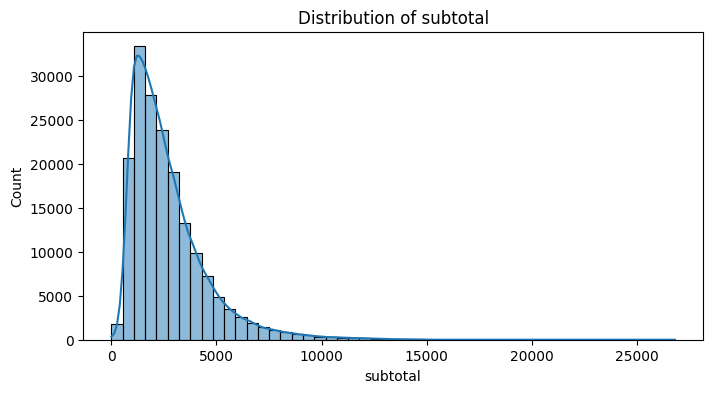

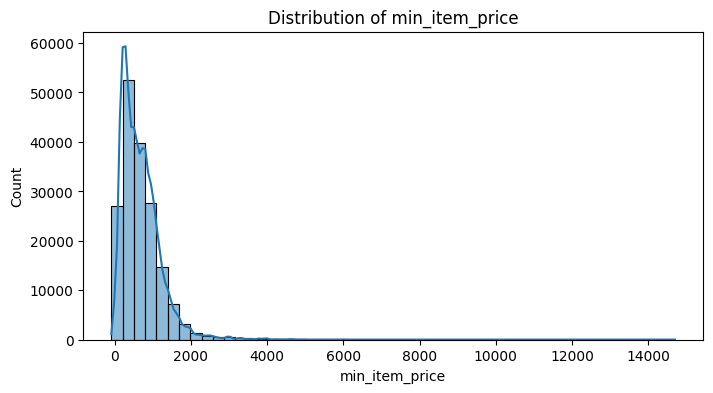

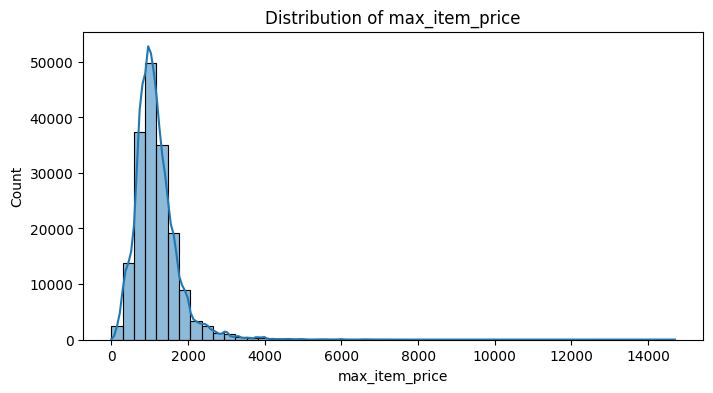

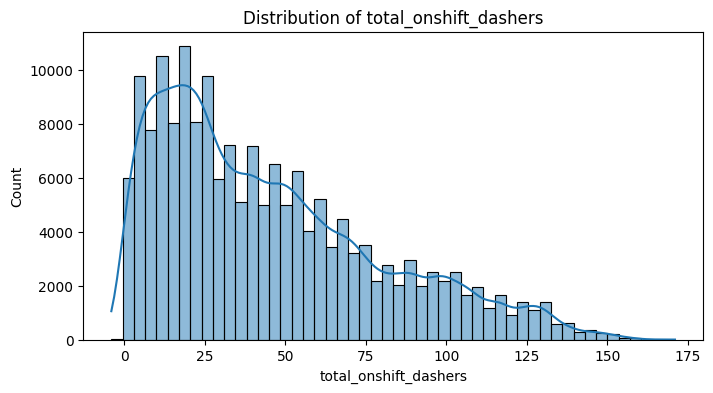

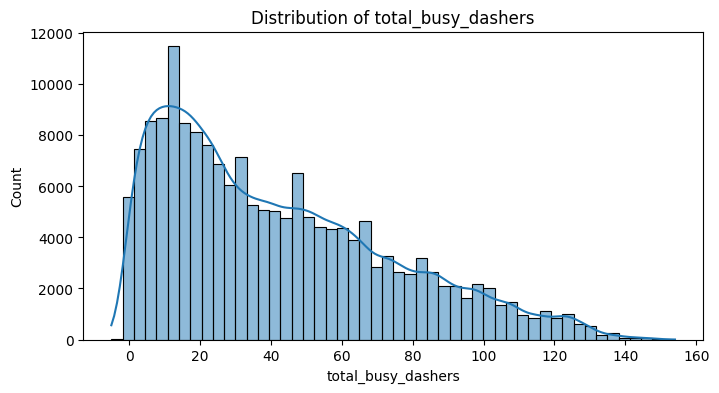

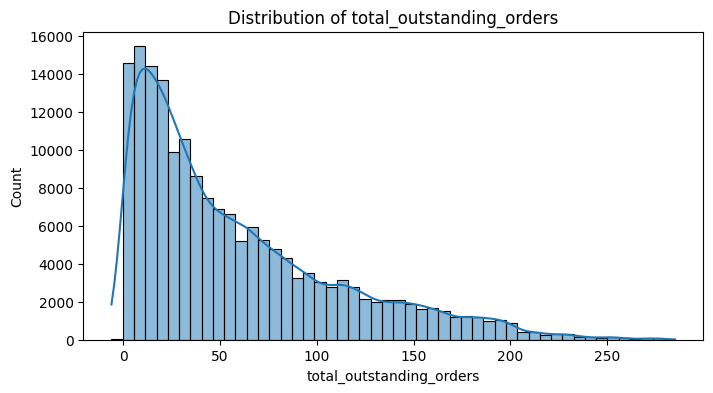

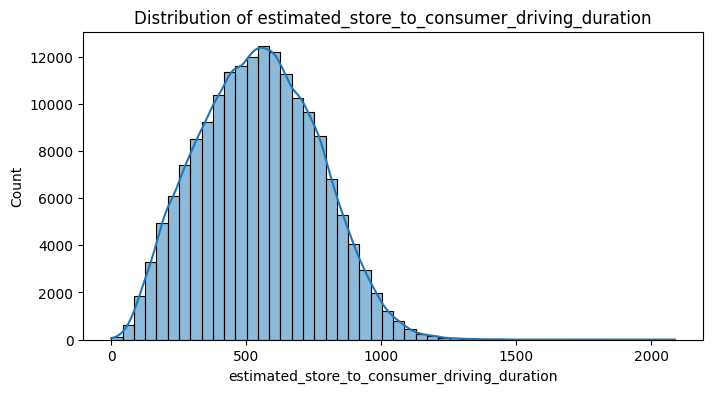

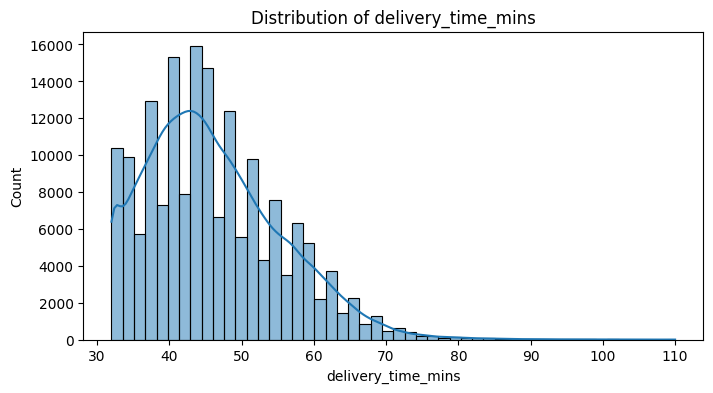

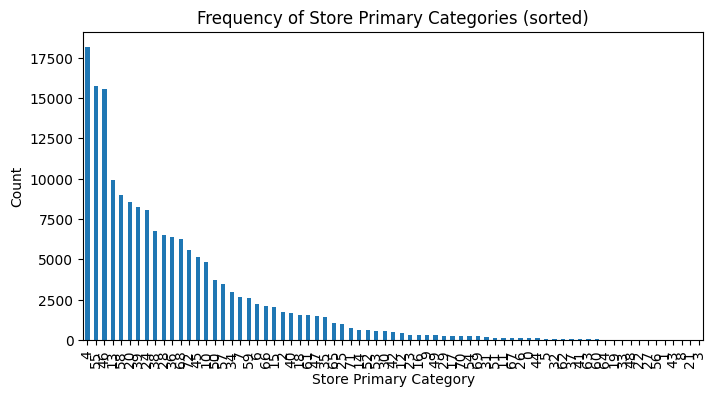

In [ ]:
# Univariate analysis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define continuous variables
continuous_vars = [
     'subtotal', 'min_item_price', 'max_item_price',
    'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders',
    'estimated_store_to_consumer_driving_duration', 'delivery_time_mins'
]

# Define continous discrete variables
continous_dis_vars = ['store_primary_category']

# Plot continuous variables with histogram + KDE
for col in continuous_vars:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col],kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.show()

# Plot continous discrete variables with countplot
for col in continous_dis_vars:
    plt.figure(figsize=(8, 4))
    counts = df['store_primary_category'].value_counts().sort_values(ascending=False)
    counts.plot(kind='bar')
    plt.title('Frequency of Store Primary Categories (sorted)')
    plt.xlabel('Store Primary Category')
    plt.ylabel('Count')
    plt.show()


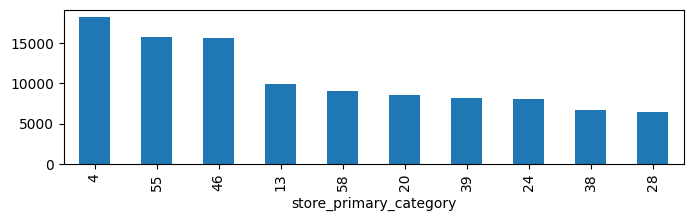

In [ ]:
df['store_primary_category'].value_counts()[:10].plot(kind='bar', figsize = (8, 2))
plt.show()

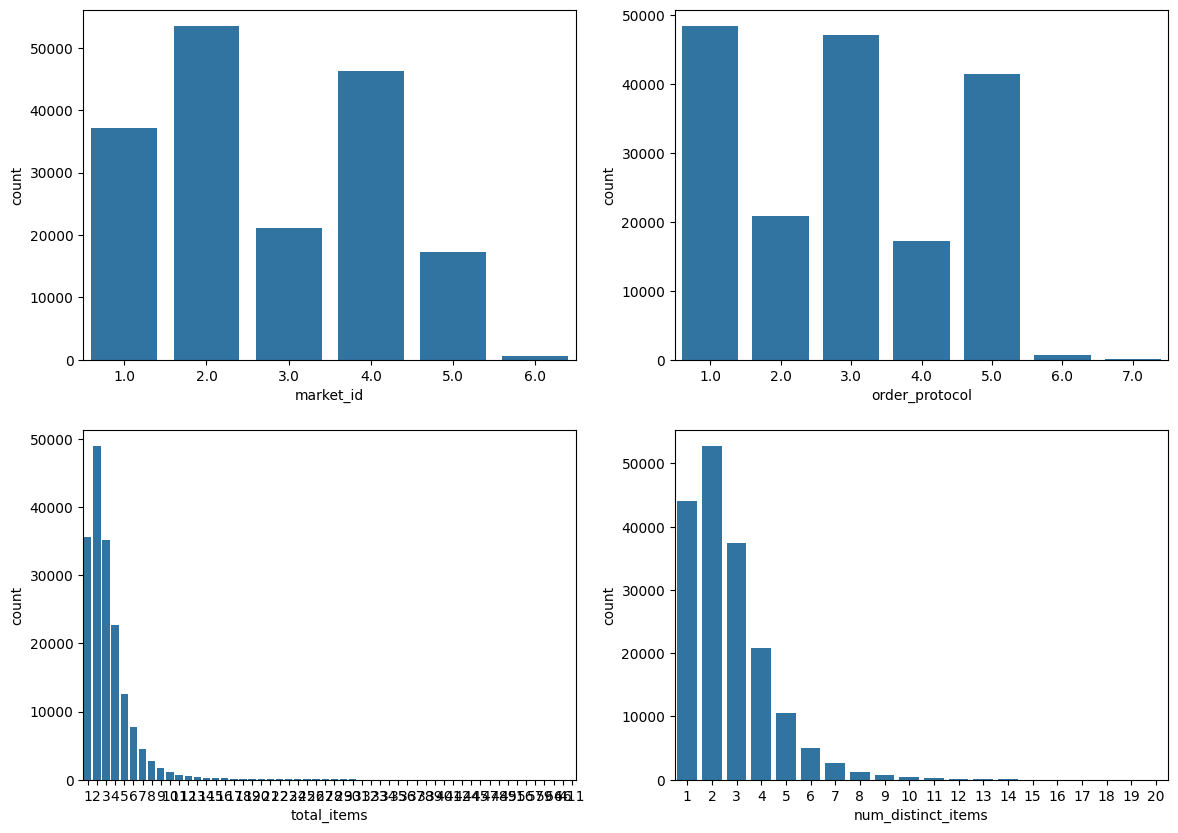

In [ ]:
# Univariate analysis for numerical discrete values
fig, axes = plt.subplots(2,2,figsize=(14,10))
sns.countplot(ax=axes[0,0], data=df, x='market_id')
sns.countplot(ax=axes[0,1], data=df, x='order_protocol')
sns.countplot(ax=axes[1,0], data=df, x='total_items',orient='h')
sns.countplot(ax=axes[1,1], data=df, x='num_distinct_items')
plt.show()

**Insights**

*   Majority of orders fall within the range Rs 500 to Rs 4000 as per subtotal column


*   Majority of min_item_price and max_item_price are in the range of Rs 0 to 2000
*   The columns 'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders','estimated_store_to_consumer_driving_duration', 'delivery_time_mins' seems to follow similar kind of distribution and are right skewed.


*   Majority of orders are delivered from 4 store primary category
*   Market id 2 is major contributor in this data


*   Majority of order placement are through protocal 1 and 3
*   Majority of orders have 2 num_distinct_items as well as 2 total_items













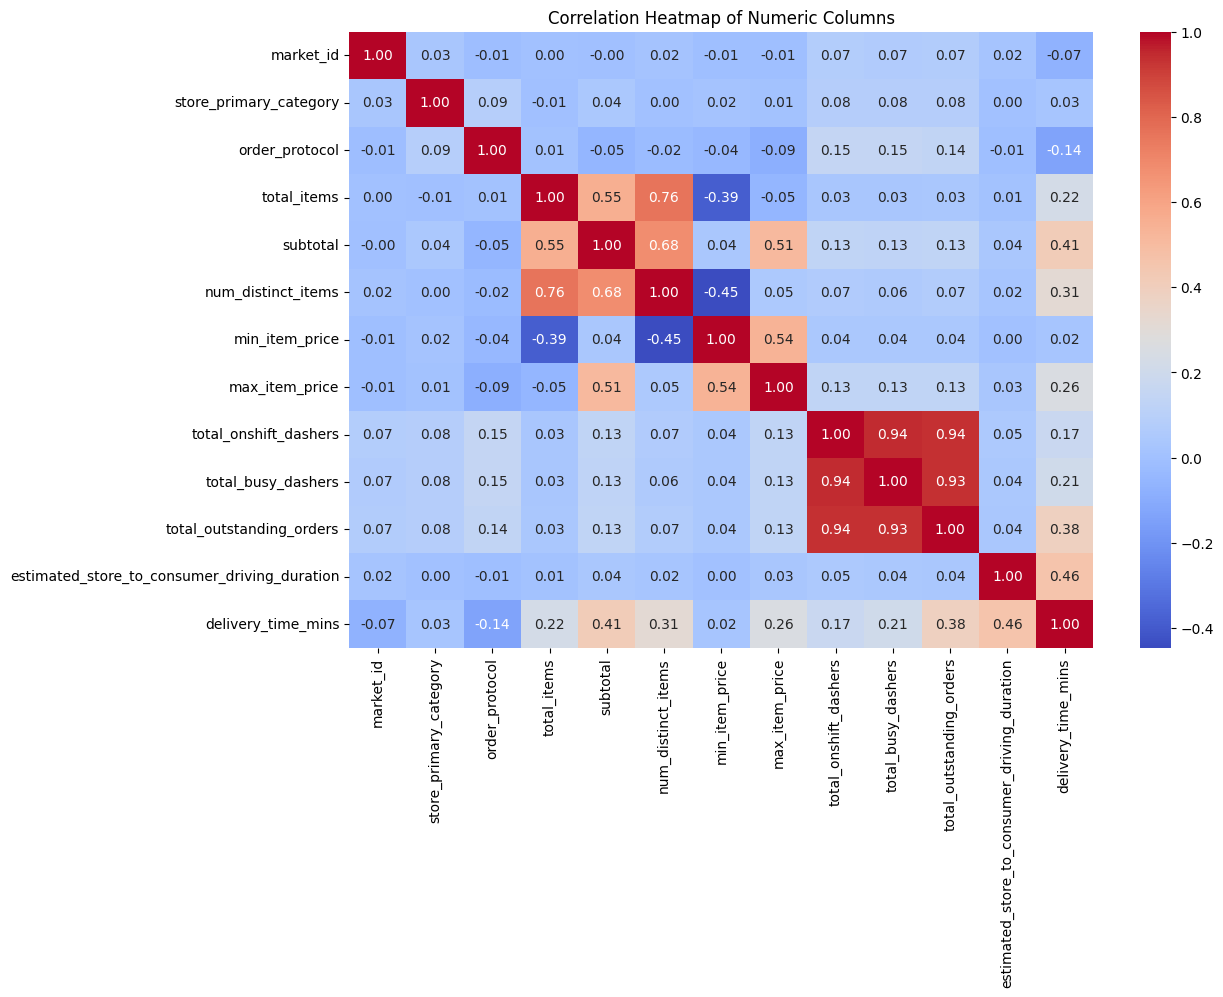

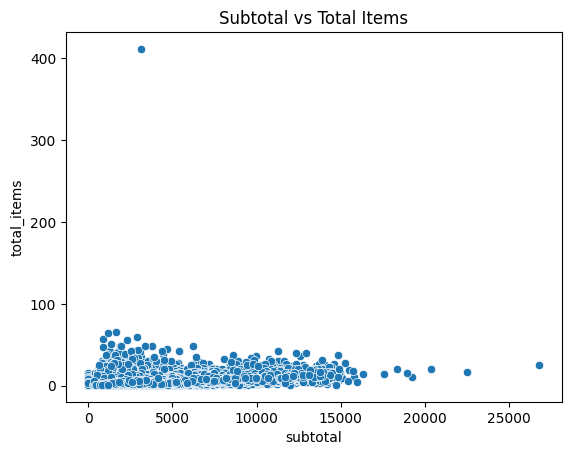

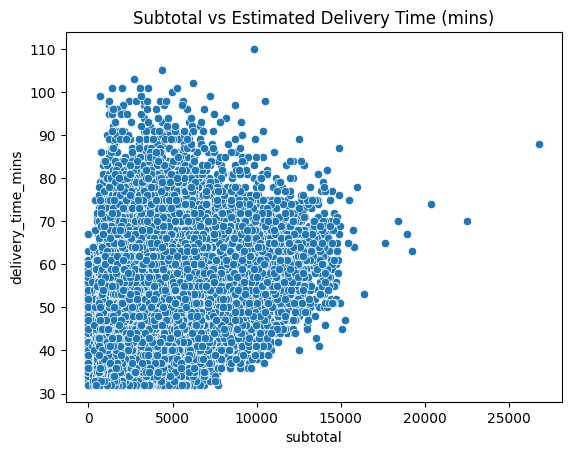

In [ ]:
#Bivariate analysis
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Columns")
plt.show()

# Example scatter plots
sns.scatterplot(x='subtotal', y='total_items', data=df)
plt.title("Subtotal vs Total Items")
plt.show()

sns.scatterplot(x='subtotal', y='delivery_time_mins', data=df)
plt.title("Subtotal vs Estimated Delivery Time (mins)")
plt.show()


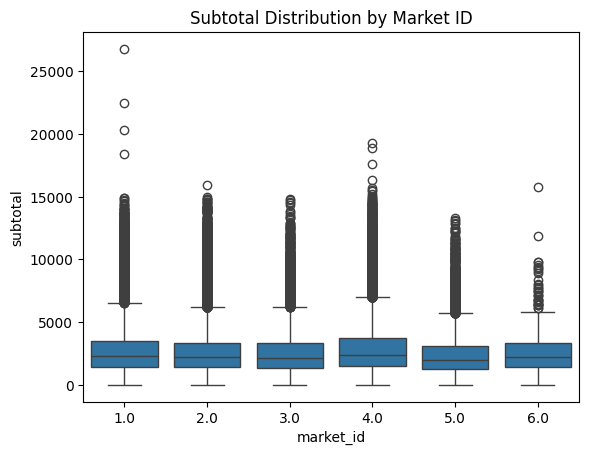

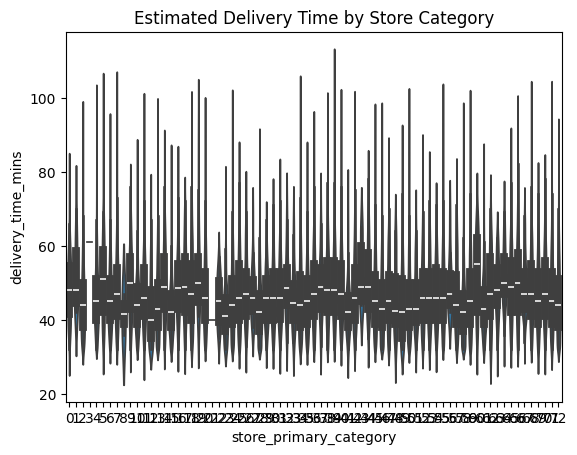

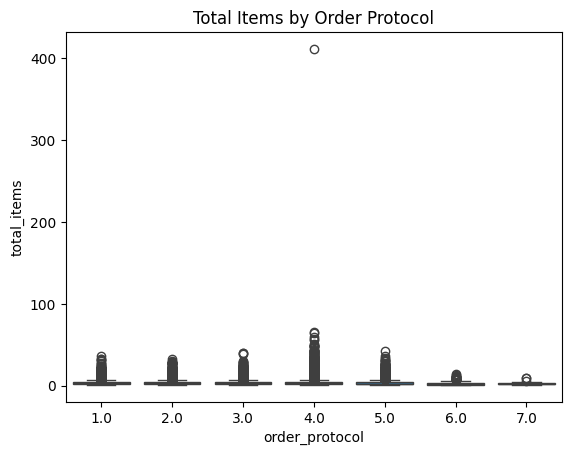

In [ ]:
# Boxplot: subtotal by market
sns.boxplot(x='market_id', y='subtotal', data=df)
plt.title("Subtotal Distribution by Market ID")
plt.show()

# Violin plot: delivery time by store category
sns.violinplot(x='store_primary_category', y='delivery_time_mins', data=df)
plt.title("Estimated Delivery Time by Store Category")
plt.show()

# Boxplot: total items by order protocol
sns.boxplot(x='order_protocol', y='total_items', data=df)
plt.title("Total Items by Order Protocol")
plt.show()


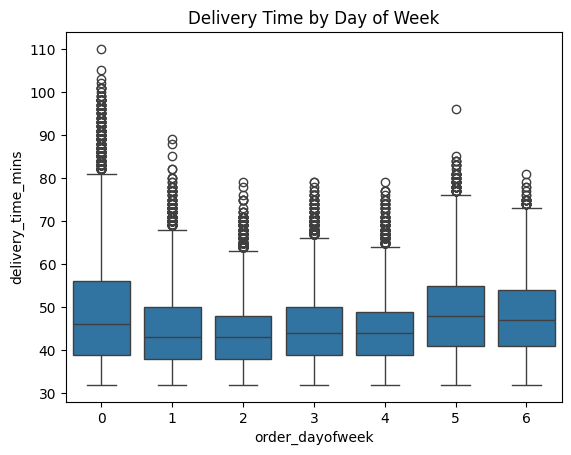

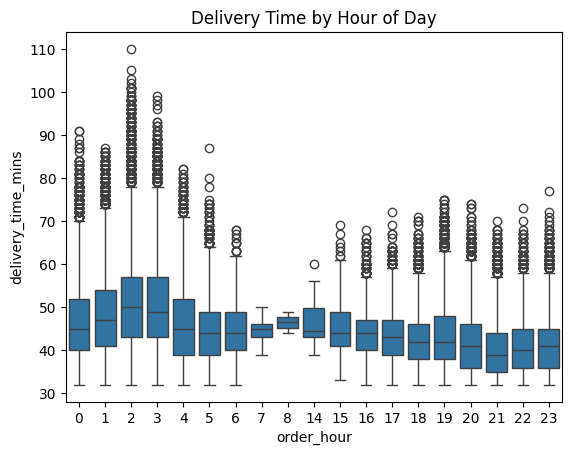

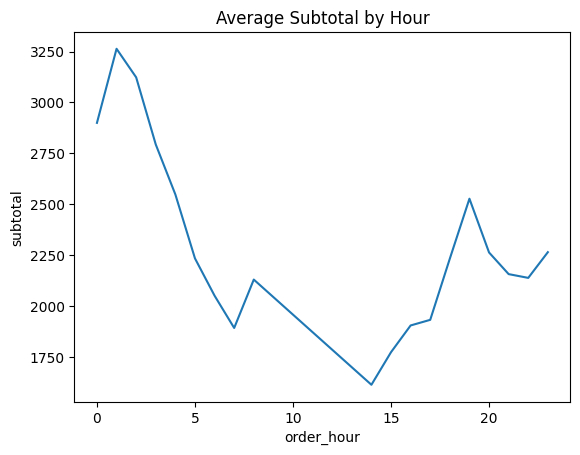

In [ ]:
# Create hourly order volume
df['order_hour'] = df['created_at'].dt.hour
df['order_dayofweek']=df['created_at'].dt.dayofweek
sns.boxplot(x='order_dayofweek', y='delivery_time_mins', data=df)
plt.title("Delivery Time by Day of Week")
plt.show()

sns.boxplot(x='order_hour', y='delivery_time_mins', data=df)
plt.title("Delivery Time by Hour of Day")
plt.show()
# Average subtotal per hour
hourly_avg = df.groupby('order_hour')['subtotal'].mean().reset_index()
sns.lineplot(x='order_hour', y='subtotal', data=hourly_avg)
plt.title("Average Subtotal by Hour")
plt.show()


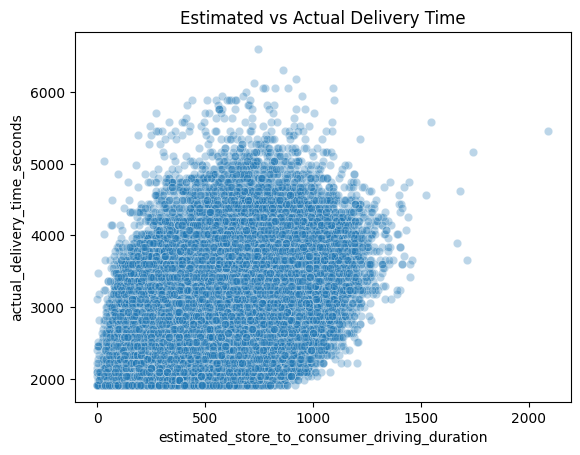

In [ ]:
df['actual_delivery_time_seconds'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds()

# Compare estimated vs actual
sns.scatterplot(x='estimated_store_to_consumer_driving_duration', y='actual_delivery_time_seconds', data=df, alpha=0.3)
plt.title("Estimated vs Actual Delivery Time")
plt.show()


In [ ]:
df.head(2)

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration,delivery_time_mins,order_hour,order_dayofweek,actual_delivery_time_seconds
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,861.0,47.0,22,4,2820.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,690.0,44.0,21,1,2640.0


# Insights



*   delivery_time_mins has slight positive correlation with estimated_store_to_consumer_driving_duration and subtotal
*   Majority of the orders are placed at around **2AM**
*   Majority of the orders are placed on **weekends**





#Outlier Treatment


In [ ]:
# Outlier treatment
for col in numeric_cols:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df_cleaned = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [ ]:
df_cleaned.shape

(174028, 18)

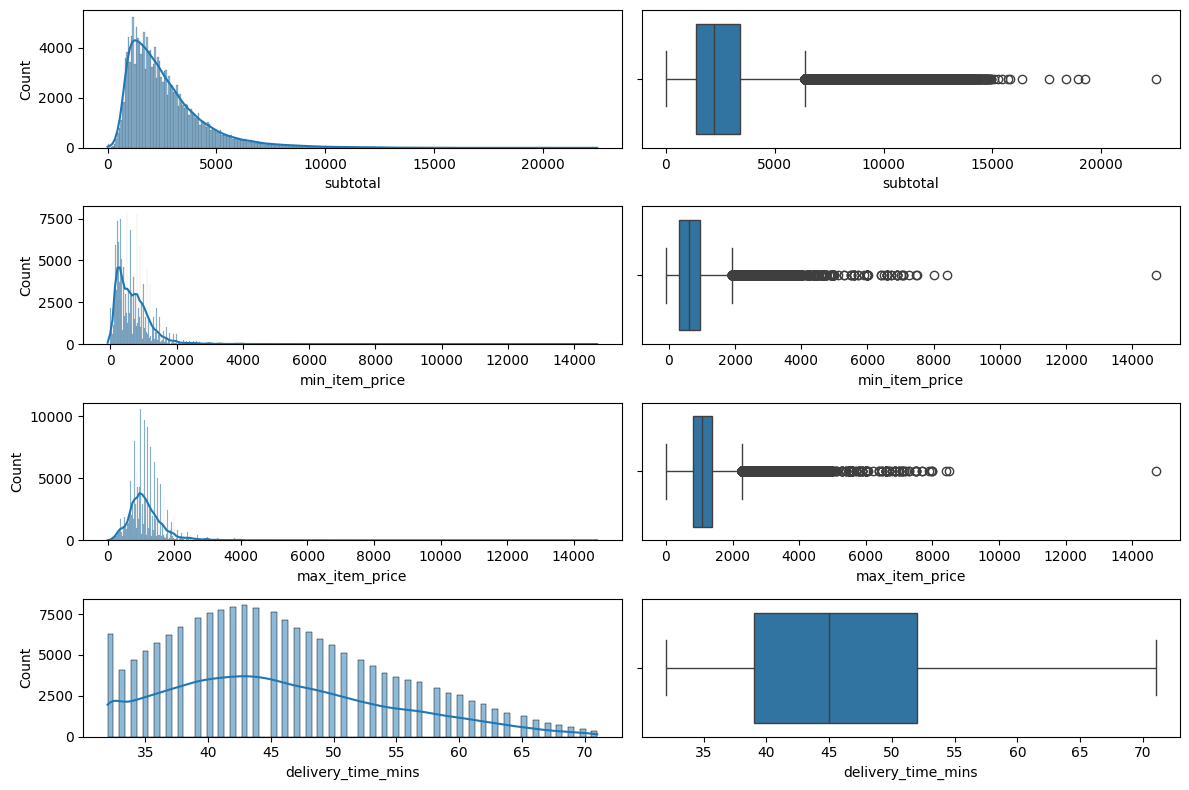

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize = (12, 8))
sns.histplot(data=df_cleaned, x = "subtotal", kde=True, ax=axes[0,0])
sns.boxplot(data=df_cleaned, x = "subtotal", ax=axes[0,1])
sns.histplot(data=df_cleaned, x = "min_item_price", kde=True, ax=axes[1,0])
sns.boxplot(data=df_cleaned, x = "min_item_price", ax=axes[1,1])
sns.histplot(data=df_cleaned, x = "max_item_price", kde=True, ax=axes[2,0])
sns.boxplot(data=df_cleaned, x = "max_item_price", ax=axes[2,1])
sns.histplot(data=df_cleaned, x = "delivery_time_mins", kde=True, ax=axes[3,0])
sns.boxplot(data=df_cleaned, x = "delivery_time_mins", ax=axes[3,1])
plt.tight_layout()
plt.show()

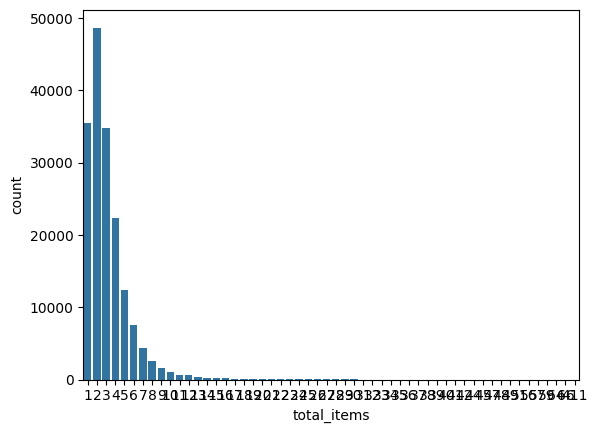

In [ ]:
sns.countplot(data=df_cleaned, x='total_items')
plt.show()

### Insight
- The distribution of data looks better after removal of outliers
- It can be seen that most of the delivery is done in **45mins**

# RF Modelling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
y=df_cleaned['delivery_time_mins']
x=df_cleaned.drop(['delivery_time_mins','actual_delivery_time_seconds','created_at','actual_delivery_time'],axis=1)
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
regressor=RandomForestRegressor()
regressor.fit(X_train,y_train)

RandomForestRegressor()

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
prediction=regressor.predict(X_test)
mse=mean_squared_error(y_test,prediction)
rmse=mse**.5
print("mse : ",mse)
print("rmse : ",rmse)
mae=mean_absolute_error(y_test,prediction)
print("mase : ",mae)
mape=np.mean(np.abs((y_test - prediction)/y_test))*100
print("mape : ",mape)

x=r2_score(y_test,prediction)
print("r2_score : ",x)

mse :  3.034864914095271
rmse :  1.7420863681503482
mase :  1.27162270872838
mape :  2.770015450606544


0.9608970570259513

# NN Modelling

Training a NN model

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
# Split data into features and target
y = df_cleaned['delivery_time_mins']
X = df_cleaned.drop(['delivery_time_mins','actual_delivery_time_seconds','created_at','actual_delivery_time'], axis=1)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Initialize the model
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(units=64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden layer(s) – tune based on complexity
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2))  # Prevent overfitting

# Output layer
model.add(Dense(units=1))  # Use activation='sigmoid' for classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])


In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=128,
    verbose=1
)


Epoch 1/30
871/871 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 754.5484 - mae: 20.9270 - val_loss: 25.6018 - val_mae: 3.9006
Epoch 2/30
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 53.3573 - mae: 5.7215 - val_loss: 10.9015 - val_mae: 2.4350
Epoch 3/30
871/871 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 40.9715 - mae: 4.9989 - val_loss: 6.2229 - val_mae: 1.8727
Epoch 4/30
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 37.7325 - mae: 4.8088 - val_loss: 4.7678 - val_mae: 1.6380
Epoch 5/30
871/871 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 35.9145 - mae: 4.6782 - val_loss: 3.2267 - val_mae: 1.3145
Epoch 6/30
871/871 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 34.9701 - mae: 4.6132 - val_loss: 3.0348 - val_mae: 1.2842
Epoch 7/30
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 34.3382 - mae: 4.5736 - val_loss: 4.6561 - val_mae: 1.7307
Epoch 8/30
871/871 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 33.4441 - mae: 4.5064 - val_loss: 2.4420 - val_mae: 1.1795
Epoch 9/30
871/871 ━━━━━━━━━━━━━━━━━━━━ 2s 3

In [ ]:
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)
print(f"Test MAE: {test_mae:.2f} minutes")


1088/1088 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9055 - mae: 0.7371
Test MAE: 0.74 minutes


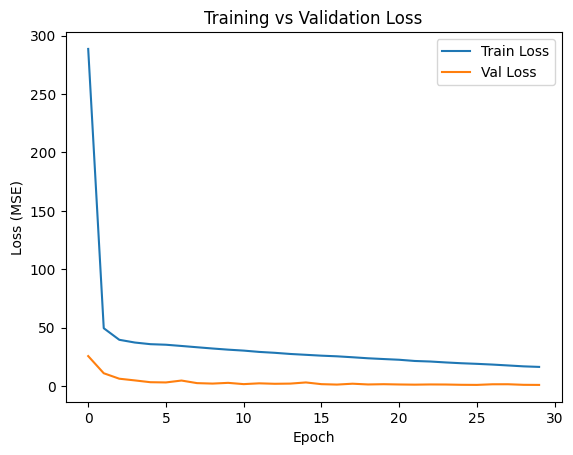

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.show()


In [ ]:
pip install keras-tuner --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.2 MB/s eta 0:00:00


In [ ]:
from kerastuner.tuners import RandomSearch
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError

def build_model(hp):
    model = Sequential()

    # Input + 1st hidden layer
    model.add(Dense(units=hp.Int('units1', min_value=32, max_value=128, step=32),
                    activation='relu',
                    input_shape=(X_train_scaled.shape[1],)))

    # 2nd hidden layer
    model.add(Dense(units=hp.Int('units2', min_value=16, max_value=64, step=16),
                    activation='relu'))

    # Dropout layer
    model.add(Dropout(rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)))

    # Output layer
    model.add(Dense(1))

    # Compile with variable learning rate
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss=MeanSquaredError(),
        metrics=['mae']
    )

    return model


In [ ]:
from kerastuner.tuners import RandomSearch

tuner = RandomSearch(
    build_model,
    objective='val_mae',
    max_trials=10,
    executions_per_trial=1,
    directory='hyperparam_tuning',
    project_name='delivery_time_model'
)


In [ ]:
tuner.search(X_train_scaled, y_train,
             validation_split=0.2,
             epochs=20,
             batch_size=64,
             callbacks=[],
             verbose=1)


Trial 10 Complete [00h 02m 18s]
val_mae: 0.5569111108779907

Best val_mae So Far: 0.45113202929496765
Total elapsed time: 00h 22m 20s


In [ ]:
# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Show best hyperparameters
best_hyperparams = tuner.get_best_hyperparameters(1)[0]
print("Best Hyperparameters:")
print(best_hyperparams.values)


Best Hyperparameters:
{'units1': 96, 'units2': 64, 'dropout': 0.30000000000000004, 'learning_rate': 0.01}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError

# Final model using best hyperparameters
model = Sequential()
model.add(Dense(units=32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))  # Output layer for regression

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=MeanSquaredError(),
    metrics=['mae']
)

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    verbose=1
)


Epoch 1/30
1741/1741 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 127.1792 - mae: 6.5654 - val_loss: 2.7402 - val_mae: 1.3009
Epoch 2/30
1741/1741 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 16.3073 - mae: 3.1531 - val_loss: 1.4145 - val_mae: 0.8663
Epoch 3/30
1741/1741 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 14.0276 - mae: 2.9152 - val_loss: 1.3425 - val_mae: 0.8595
Epoch 4/30
1741/1741 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 11.3024 - mae: 2.5916 - val_loss: 1.6699 - val_mae: 1.0295
Epoch 5/30
1741/1741 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 8.6334 - mae: 2.2594 - val_loss: 0.4743 - val_mae: 0.5333
Epoch 6/30
1741/1741 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 6.1173 - mae: 1.8811 - val_loss: 1.6759 - val_mae: 1.1070
Epoch 7/30
1741/1741 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 4.5186 - mae: 1.5917 - val_loss: 0.3439 - val_mae: 0.4587
Epoch 8/30
1741/1741 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 3.2571 - mae: 1.3253 - val_loss: 0.3330 - val_mae: 0.4422
Epoch 9/30
1741/1741 ━━━━━━━━━━━━━

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,973 (31.15 KB)

 Trainable params: 2,657 (10.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,316 (20.77 KB)

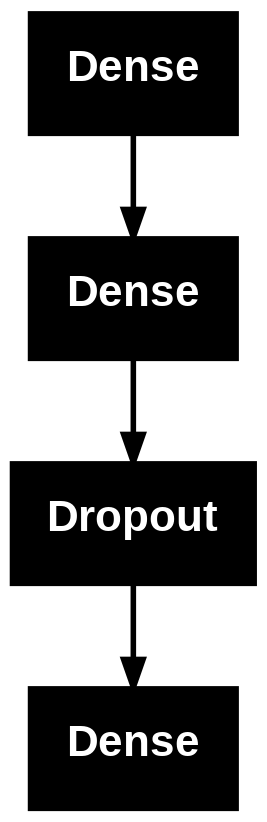

In [ ]:
model.summary()
from tensorflow.keras.utils import plot_model
plot_model(model)

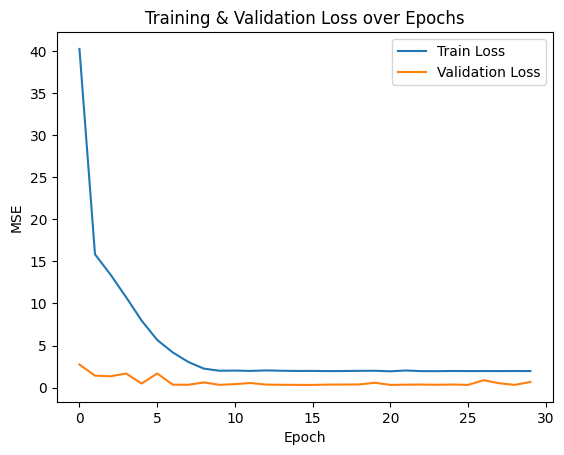

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()


In [ ]:
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)
print(f"Test MAE (final tuned model): {test_mae:.2f} minutes")


1088/1088 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6680 - mae: 0.6809
Test MAE (final tuned model): 0.68 minutes


1088/1088 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


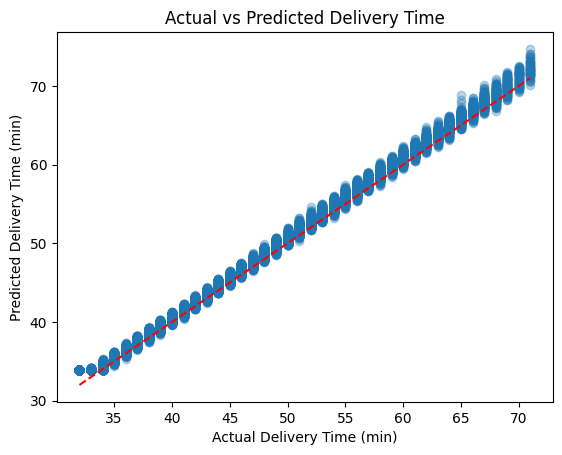

In [ ]:
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_scaled).flatten()

plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel('Actual Delivery Time (min)')
plt.ylabel('Predicted Delivery Time (min)')
plt.title('Actual vs Predicted Delivery Time')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


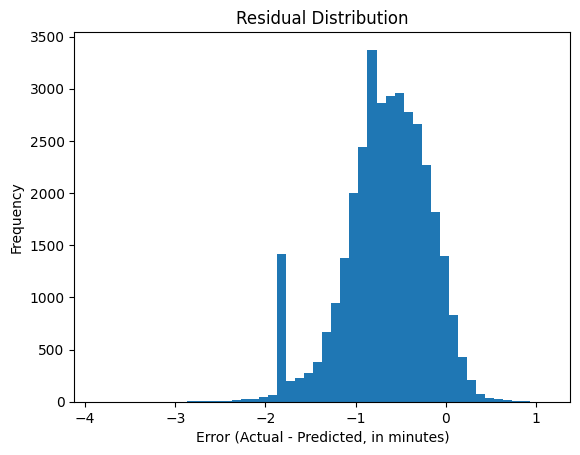

In [ ]:
residuals = y_test - y_pred
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.xlabel("Error (Actual - Predicted, in minutes)")
plt.ylabel("Frequency")
plt.show()


# Recommendations and insights

**Reducing delivery time and increasing ETA prediction accuracy directly improves Porter-aligned KPIs like:**

On-time delivery rate

Customer satisfaction (CSAT)

Operational throughput

**The model is strongly influenced by:**

Distance/time to the customer,

Dasher availability (system load),

Order complexity (items & cost),

Time of day (rush hours).

This aligns very well with business logic and operational data.

# Questionnaire
1. Defining the problem statements and where can this and modifications of this be
used?

Ans- The problem statement is to analyze the dataset to accurately predict delivery times for different orders based on various operational, temporal, and order-level features. With slight modifications this can be used in ETA of products in Food, Grocery, Pharma, E-commerce, Logistics or even in ETA of Cab in Cab bookings.

2. List 3 functions the pandas datetime provides with one line explanation.

Ans- They are as follows;

pd.to_datetime(): Converts strings or other formats into datetime64 objects for time-based operations.

.dt.hour / .dt.dayofweek / .dt.month:  Extracts specific components (like hour, weekday, or month) from datetime columns.

.dt.floor('H') / .dt.round('min'):   Rounds datetime values to the nearest or lower specified time frequency (e.g., hour, minute).

3. Short note on datetime, timedelta, time span (period)

Ans-
datetime- Represents a specific point in time (date + time).
Example: 2025-06-19 10:30:00
Used to track when something happened.

timedelta- Represents a duration or time difference between two dates/times.
Example: pd.Timedelta("2 days 3 hours")
Used for date arithmetic, like "2 days from now".

Period (Time Span)- Represents a span of time like a day, month, or year.
Example: pd.Period("2023-04", freq="M") → April 2023
Useful for grouping or indexing by time intervals.

4. Why do we need to check for outliers in our data?

Ans- We need to check for outliers in our data because they can significantly distort model accuracy, especially in regression tasks, by skewing averages and inflating error metrics like Mean Squared Error (MSE). Outliers may also signal data quality issues such as input errors, missing preprocessing steps, or system glitches—for example, unrealistically short or long delivery times. Additionally, they can affect feature scaling techniques like MinMaxScaler, compressing the majority of data into narrow ranges and reducing model sensitivity. Identifying and handling outliers ensures cleaner, more reliable models and leads to more meaningful business insights.

5. Name 3 outlier removal methods?

Ans-
Z-Score Method- Removes data points with a Z-score beyond a threshold (e.g., > 3 or < -3), indicating they’re far from the mean.

IQR Method (Interquartile Range)- Identifies outliers as values outside 1.5 × IQR beyond Q1 or Q3 (below Q1 - 1.5×IQR or above Q3 + 1.5×IQR).

Isolation Forest / One-Class SVM (Model-Based)- Machine learning-based methods that detect outliers by learning patterns and isolating anomalies in the data.

6. What classical machine learning methods can we use for this problem?

Ans-  Linear Regression, Decision Tree Regressor,Random Forest Regressor

7. Why is scaling required for neural networks?

Ans- Scaling is crucial for neural networks because it ensures that all input features contribute equally during training. Without scaling, features with larger values can dominate gradient updates, leading to slower convergence and unstable training. Scaling also helps prevent issues like vanishing or exploding gradients and improves model accuracy by allowing the network to learn meaningful patterns rather than just magnitudes.

8. Briefly explain your choice of optimizer.

Ans-The Adam optimizer was used because it adapts the learning rate for each parameter individually by using estimates of first and second moments of the gradients. This leads to faster and more stable convergence compared to standard methods like SGD. Adam is also robust to noisy data and requires less manual tuning, making it a reliable and efficient choice for a wide range of models.

9. Which activation function did you use and why?

Ans- the ReLU (Rectified Linear Unit) activation function because it introduces non-linearity while being simple and computationally efficient. ReLU helps the model learn complex patterns by allowing positive values to pass through unchanged and setting negative values to zero, which also helps reduce the vanishing gradient problem during training.

10. Why does a neural network perform well on a large dataset?

Ans-A neural network performs well on a large dataset because it has enough data to learn complex patterns and generalize effectively. Large datasets provide diverse examples, helping the network avoid overfitting and capture the underlying relationships in the data. Additionally, more data allows the network’s many parameters to be properly trained, improving its ability to make accurate predictions on new, unseen data.